<a href="https://colab.research.google.com/github/risingsoul1729/Exploratory_project/blob/main/XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv('/battery_cycle_level_dataset_CLEAN_FINAL.csv')

In [ ]:
test_battery_id = 'B0018'
train_df = df[df['battery_id'] != test_battery_id].copy()
test_df = df[df['battery_id'] == test_battery_id].copy()

In [ ]:
feature_cols = ['cycle', 'voltage', 'temperature', 'capacity']
target_cols = ['soh', 'rul']
X_train = train_df[feature_cols]
y_train = train_df[target_cols]
X_test = test_df[feature_cols]
y_test = test_df[target_cols]

In [ ]:
feature_scaler = MinMaxScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train)
y_test_scaled = target_scaler.transform(y_test)

In [ ]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist' # Highly optimized for SaaS/cloud processing
)

In [ ]:
print("Training multi-target model on NASA dataset...")
model.fit(X_train_scaled, y_train_scaled)

Training multi-target model on NASA dataset...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_test.values
soh_pred = y_pred_actual[:, 0]
rul_pred = y_pred_actual[:, 1]
soh_true = y_test_actual[:, 0]
rul_true = y_test_actual[:, 1]

In [ ]:
print(f"\n--- Evaluation on Unseen Test Battery: {test_battery_id} ---")
print(f"SoH Mean Absolute Error: {mean_absolute_error(soh_true, soh_pred):.4f}")
print(f"RUL Mean Absolute Error: {mean_absolute_error(rul_true, rul_pred):.1f} cycles")


--- Evaluation on Unseen Test Battery: B0018 ---
SoH Mean Absolute Error: 0.0269
RUL Mean Absolute Error: 12.3 cycles


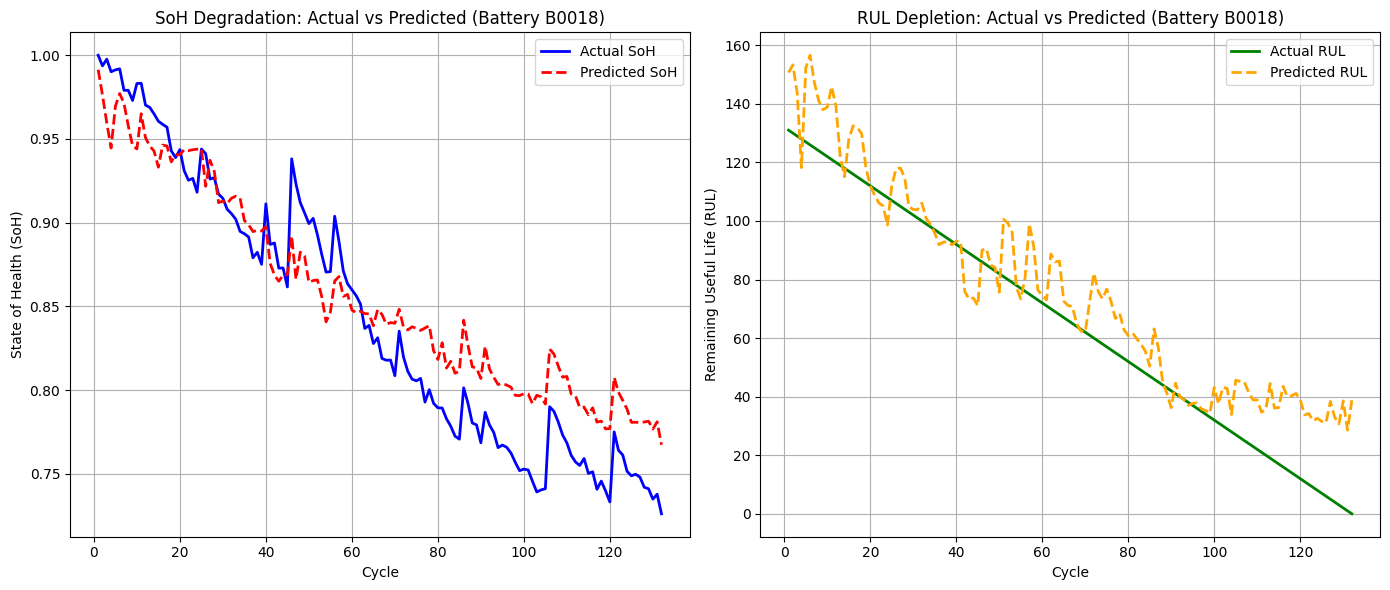

In [ ]:
cycles_test = test_df['cycle'].values
plt.figure(figsize=(14, 6))
# Subplot 1: State of Health (SoH)
plt.subplot(1, 2, 1)
plt.plot(cycles_test, soh_true, label='Actual SoH', color='blue', linewidth=2)
plt.plot(cycles_test, soh_pred, label='Predicted SoH', color='red', linestyle='--', linewidth=2)
plt.xlabel('Cycle')
plt.ylabel('State of Health (SoH)')
plt.title(f'SoH Degradation: Actual vs Predicted (Battery {test_battery_id})')
plt.legend()
plt.grid(True)

# Subplot 2: Remaining Useful Life (RUL)
plt.subplot(1, 2, 2)
plt.plot(cycles_test, rul_true, label='Actual RUL', color='green', linewidth=2)
plt.plot(cycles_test, rul_pred, label='Predicted RUL', color='orange', linestyle='--', linewidth=2)
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (RUL)')
plt.title(f'RUL Depletion: Actual vs Predicted (Battery {test_battery_id})')
plt.legend()
plt.grid(True)

# Adjust layout to prevent overlap and display the graphs
plt.tight_layout()
plt.show()